# Lab 5 : Exploratory Data Analysis



---



## Import Thai Font 

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

font_path = 'THSarabunNew.ttf'
font_manager.fontManager.addfont(font_path)
rcParams['font.family'] = 'TH Sarabun New'

If output's graph have these example texts "**กราฟตัวอย่าง(Example)**", "**แกน X(X-axis)**", and "**แกน Y(Y-axis)**", Then it's work.



---


## Read example data



---




In [16]:
province_fix_map = {
    'กรงเทพมหานคร': 'กรุงเทพมหานคร',
    'กระบ': 'กระบี่',
    'กาญจนบร': 'กาญจนบุรี',
    'กาฬสนธ': 'กาฬสินธุ์',
    'กำแพงเพชร': 'กำแพงเพชร',
    'ขอนแกน': 'ขอนแก่น',
    'จนทบร': 'จันทบุรี',
    'ฉะเชงเทรา': 'ฉะเชิงเทรา',
    'ชมพร': 'ชุมพร',
    'ชยนาท': 'ชัยนาท',
    'ชยภม': 'ชัยภูมิ',
    'ชลบร': 'ชลบุรี',
    'ตรง': 'ตรัง',
    'ตราด': 'ตราด',
    'ตาก': 'ตาก',
    'นครนายก': 'นครนายก',
    'นครปฐม': 'นครปฐม',
    'นครพนม': 'นครพนม',
    'นครราชสมา': 'นครราชสีมา',
    'นครศรธรรมราช': 'นครศรีธรรมราช',
    'นครสวรรค': 'นครสวรรค์',
    'นนทบร': 'นนทบุรี',
    'นราธวาส': 'นราธิวาส',
    'นาน': 'น่าน',
    'บงกาฬ': 'บึงกาฬ',
    'บรรมย': 'บุรีรัมย์',
    'ปตตาน': 'ปัตตานี',
    'ปทมธาน': 'ปทุมธานี',
    'ประจวบครขนธ': 'ประจวบคีรีขันธ์',
    'ปราจนบร': 'ปราจีนบุรี',
    'พงงา': 'พังงา',
    'พจตร': 'พิจิตร',
    'พทลง': 'พัทลุง',
    'พระนครศรอยธยา': 'พระนครศรีอยุธยา',
    'พษณโลก': 'พิษณุโลก',
    'พะเยา': 'พะเยา',
    'ภเกต': 'ภูเก็ต',
    'มกดาหาร': 'มุกดาหาร',
    'มหาสารคาม': 'มหาสารคาม',
    'ยะลา': 'ยะลา',
    'ยโสธร': 'ยโสธร',
    'รอยเอด': 'ร้อยเอ็ด',
    'ระนอง': 'ระนอง',
    'ระยอง': 'ระยอง',
    'ราชบร': 'ราชบุรี',
    'ลพบร': 'ลพบุรี',
    'ลำปาง': 'ลำปาง',
    'ลำพน': 'ลำพูน',
    'ศรสะเกษ': 'ศรีสะเกษ',
    'สกลนคร': 'สกลนคร',
    'สงขลา': 'สงขลา',
    'สงหบร': 'สิงห์บุรี',
    'สตล': 'สตูล',
    'สพรรณบร': 'สุพรรณบุรี',
    'สมทรปราการ': 'สมุทรปราการ',
    'สมทรสงคราม': 'สมุทรสงคราม',
    'สมทรสาคร': 'สมุทรสาคร',
    'สรนทร': 'สุรินทร์',
    'สระบร': 'สระบุรี',
    'สระแกว': 'สระแก้ว',
    'สราษฎรธาน': 'สุราษฎร์ธานี',
    'สโขทย': 'สุโขทัย',
    'หนองคาย': 'หนองคาย',
    'หนองบวลำภ': 'หนองบัวลำภู',
    'อดรธาน': 'อุดรธานี',
    'อตรดตถ': 'อุตรดิตถ์',
    'อทยธาน': 'อุทัยธานี',
    'อบลราชธาน': 'อุบลราชธานี',
    'อางทอง': 'อ่างทอง',
    'อำนาจเจรญ': 'อำนาจเจริญ',
    'เชยงราย': 'เชียงราย',
    'เชยงใหม': 'เชียงใหม่',
    'เพชรบร': 'เพชรบุรี',
    'เพชรบรณ': 'เพชรบูรณ์',
    'เลย': 'เลย',
    'แพร': 'แพร่',
    'แมฮองสอน': 'แม่ฮ่องสอน'
}

In [17]:
import os
import pandas as pd

root_dir = './all_constituency'
all_data = []

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file == 'constituency_candidates.csv':
            file_path = os.path.join(subdir, file)
            
            parts = subdir.split(os.sep)
            
            if len(parts) >= 3:
                province = parts[-2]      # จ
                constituency = parts[-1]  # เขต
                province_fix = province_fix_map[province]
                constituency_fix = constituency.replace(province,province_fix)
                
                try:
                    temp_df = pd.read_csv(file_path, encoding='utf-8-sig')

                    temp_df['province'] = province_fix
                    temp_df['constituency'] = constituency_fix
                    
                    all_data.append(temp_df)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)

    cols = ['province', 'constituency'] + [c for c in df.columns if c not in ['province', 'constituency']]
    df = df[cols]

print(df.head())

        province         constituency                fullName  totalVotes  \
0  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1  ปารเมศ วิทยารักษ์สรรค์       32564   
1  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1      พีรวุฒิ พิมพ์สมฤดี       14018   
2  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1      ลลิดา เพริศวิวัฒนา       13661   
3  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1    ญาณกิตติ์ ห่วงทรัพย์        5761   
4  กรุงเทพมหานคร  กรุงเทพมหานคร เขต 1  พลัฏฐ์ ศิริกุลพิสุทธิ์        1983   

   candidateNumber                 updatedAt  percent  rank  party.code  \
0                5  2026-02-07T16:49:10.564Z    44.39     1          46   
1                9  2026-02-07T16:49:14.267Z    19.11     2          27   
2                1  2026-02-07T16:49:03.079Z    18.62     3          37   
3                8  2026-02-07T16:49:13.129Z     7.85     4           9   
4                6  2026-02-07T16:49:11.214Z     2.70     5           6   

  party.color           party.name  
0     #ff6412          พรรคประชาชน  
1     #70c0f

In [18]:
df

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พีรวุฒิ พิมพ์สมฤดี,14018,9,2026-02-07T16:49:14.267Z,19.11,2,27,#70c0fd,พรรคประชาธิปัตย์
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ลลิดา เพริศวิวัฒนา,13661,1,2026-02-07T16:49:03.079Z,18.62,3,37,#131c5f,พรรคภูมิใจไทย
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ญาณกิตติ์ ห่วงทรัพย์,5761,8,2026-02-07T16:49:13.129Z,7.85,4,9,#fe0000,พรรคเพื่อไทย
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พลัฏฐ์ ศิริกุลพิสุทธิ์,1983,6,2026-02-07T16:49:11.214Z,2.70,5,6,#243180,พรรครวมไทยสร้างชาติ
...,...,...,...,...,...,...,...,...,...,...,...
3484,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,พนธกร ใจสนอง,12618,4,2026-02-07T16:49:08.376Z,19.84,3,46,#ff6412,พรรคประชาชน
3485,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,สมภพ คงความซื่อ,2068,1,2026-02-07T16:49:04.719Z,3.25,4,9,#fe0000,พรรคเพื่อไทย
3486,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,สติ ทรัพย์ทวีพันธ์,1017,3,2026-02-07T16:49:08.063Z,1.60,5,6,#243180,พรรครวมไทยสร้างชาติ
3487,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,ภานุวัฒน์ คงมีความดี,931,6,2026-02-07T16:49:11.851Z,1.46,6,27,#70c0fd,พรรคประชาธิปัตย์


In [19]:
df.isnull().sum()

province           0
constituency       0
fullName           0
totalVotes         0
candidateNumber    0
updatedAt          0
percent            0
rank               0
party.code         0
party.color        0
party.name         0
dtype: int64

In [21]:
top2_df = df[(df["rank"]==1) | (df["rank"] ==2)].reset_index()
top2_df

,index,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
1,1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พีรวุฒิ พิมพ์สมฤดี,14018,9,2026-02-07T16:49:14.267Z,19.11,2,27,#70c0fd,พรรคประชาธิปัตย์
2,18,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,เอกราช อุดมอำนวย,37489,6,2026-02-07T16:49:11.214Z,44.74,1,46,#ff6412,พรรคประชาชน
3,19,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,ภูมิพัฒน์ โหสกุล,17889,5,2026-02-07T16:49:09.941Z,21.35,2,9,#fe0000,พรรคเพื่อไทย
4,34,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน
...,...,...,...,...,...,...,...,...,...,...,...,...
795,3472,แพร่,แพร่ เขต 3,วรวัจน์ เอื้ออภิญญกุล,21142,2,2026-02-07T16:49:05.703Z,29.23,2,9,#fe0000,พรรคเพื่อไทย
796,3477,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,ปกรณ์ จีนาคำ,33724,2,2026-02-07T16:49:06.180Z,58.34,1,42,#44a26e,พรรคกล้าธรรม
797,3478,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,อนัส มณีพฤกษ์,17878,5,2026-02-07T16:49:09.633Z,30.93,2,46,#ff6412,พรรคประชาชน
798,3482,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,สมบัติ ยะสินธุ์,23410,5,2026-02-07T16:49:10.564Z,36.81,1,37,#131c5f,พรรคภูมิใจไทย


In [23]:
def calc_diff(group):
    r1 = group[group['rank'] == 1]['percent'].values[0]
    r2 = group[group['rank'] == 2]['percent'].values[0]
    return r1 - r2

percentage_diff = top2_df.groupby("constituency").apply(calc_diff)
print(percentage_diff)

constituency
กระบี่ เขต 1            33.10
กระบี่ เขต 2            27.80
กระบี่ เขต 3            36.39
กรุงเทพมหานคร เขต 1     25.28
กรุงเทพมหานคร เขต 10    23.39
                        ...  
แพร่ เขต 1              15.65
แพร่ เขต 2              53.84
แพร่ เขต 3               3.37
แม่ฮ่องสอน เขต 1        27.41
แม่ฮ่องสอน เขต 2         0.45
Length: 400, dtype: float64


In [24]:
df_diff = top2_df.pivot_table(
    index=['province', 'constituency'], 
    columns='rank', 
    values=['party.name', 'percent'],
    aggfunc='first'
).reset_index()

df_diff.columns = [
    'province', 'constituency', 
    'winner_party', 'runnerup_party', 
    'winner_percent', 'runnerup_percent'
]

df_diff['pct_diff'] = df_diff['winner_percent'] - df_diff['runnerup_percent']

df_diff = df_diff.sort_values('pct_diff').reset_index(drop=True)

In [25]:
df_diff

,province,constituency,winner_party,runnerup_party,winner_percent,runnerup_percent,pct_diff
0,นราธิวาส,นราธิวาส เขต 3,พรรคกล้าธรรม,พรรคภูมิใจไทย,45.88,45.74,0.14
1,ศรีสะเกษ,ศรีสะเกษ เขต 6,พรรคภูมิใจไทย,พรรคเพื่อไทย,39.19,38.87,0.32
2,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,พรรคภูมิใจไทย,พรรคกล้าธรรม,36.81,36.36,0.45
3,นครราชสีมา,นครราชสีมา เขต 3,พรรคประชาชน,พรรคเพื่อไทย,40.86,40.25,0.61
4,ขอนแก่น,ขอนแก่น เขต 3,พรรคกล้าธรรม,พรรคประชาชน,35.38,34.59,0.79
...,...,...,...,...,...,...,...
395,ศรีสะเกษ,ศรีสะเกษ เขต 8,พรรคภูมิใจไทย,พรรคเพื่อไทย,74.06,12.23,61.83
396,อุบลราชธานี,อุบลราชธานี เขต 10,พรรคไทรวมพลัง,พรรคประชาชน,77.07,9.16,67.91
397,บุรีรัมย์,บุรีรัมย์ เขต 10,พรรคภูมิใจไทย,พรรคประชาชน,78.89,10.28,68.61
398,บุรีรัมย์,บุรีรัมย์ เขต 3,พรรคภูมิใจไทย,พรรคประชาชน,81.58,11.61,69.97


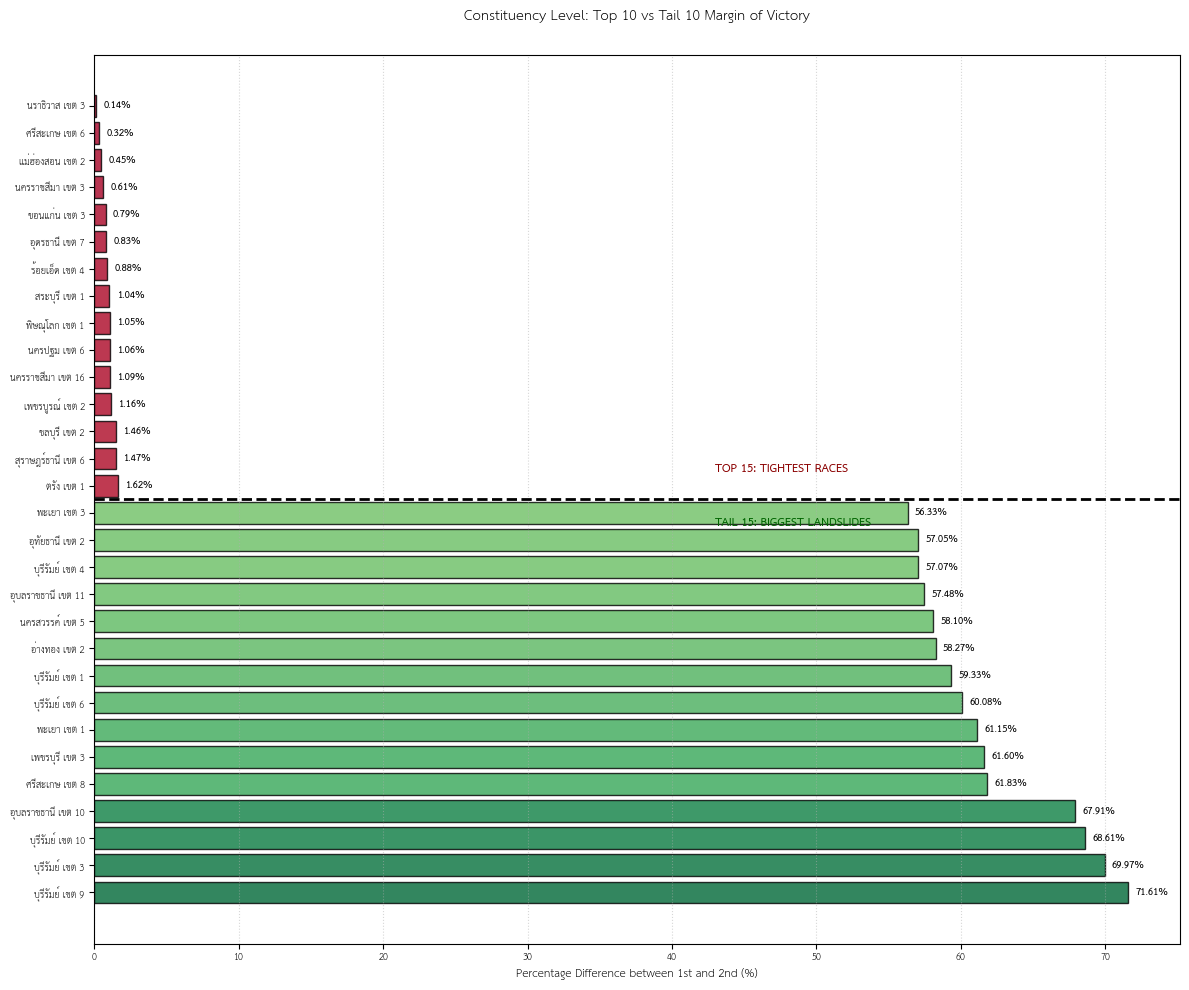

In [27]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

combined_const = pd.concat([df_diff.head(15), df_diff.tail(15)]).sort_values('pct_diff')

labels = combined_const['constituency'] 
values = combined_const['pct_diff']

norm = plt.Normalize(values.min(), values.max())
colors = cm.RdYlGn(norm(values.values))

fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(labels, values, color=colors, edgecolor='black', alpha=0.8)

split_index = 15
ax.axhline(y=split_index - 0.5, color='black', linestyle='--', linewidth=2)

ax.text(values.max()*0.6, split_index - 1.5, 'TOP 15: TIGHTEST RACES', 
        color='darkred', fontweight='bold', fontsize=12)
ax.text(values.max()*0.6, split_index + 0.5, 'TAIL 15: BIGGEST LANDSLIDES', 
        color='darkgreen', fontweight='bold', fontsize=12)

ax.set_title('Constituency Level: Top 10 vs Tail 10 Margin of Victory', fontsize=15, pad=25)
ax.set_xlabel('Percentage Difference between 1st and 2nd (%)', fontsize=12)
ax.invert_yaxis() 
ax.grid(axis='x', linestyle=':', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
province_competition = df_diff.groupby("province")["pct_diff"].mean().sort_values()
province_competition

province
ภูเก็ต           7.290000
จันทบุรี         7.390000
นครนายก          8.160000
น่าน             8.450000
สุราษฎร์ธานี     9.505714
                  ...    
อ่างทอง         52.980000
ระนอง           53.920000
เพชรบุรี        54.616667
อุทัยธานี       56.425000
บุรีรัมย์       58.955000
Name: pct_diff, Length: 77, dtype: float64

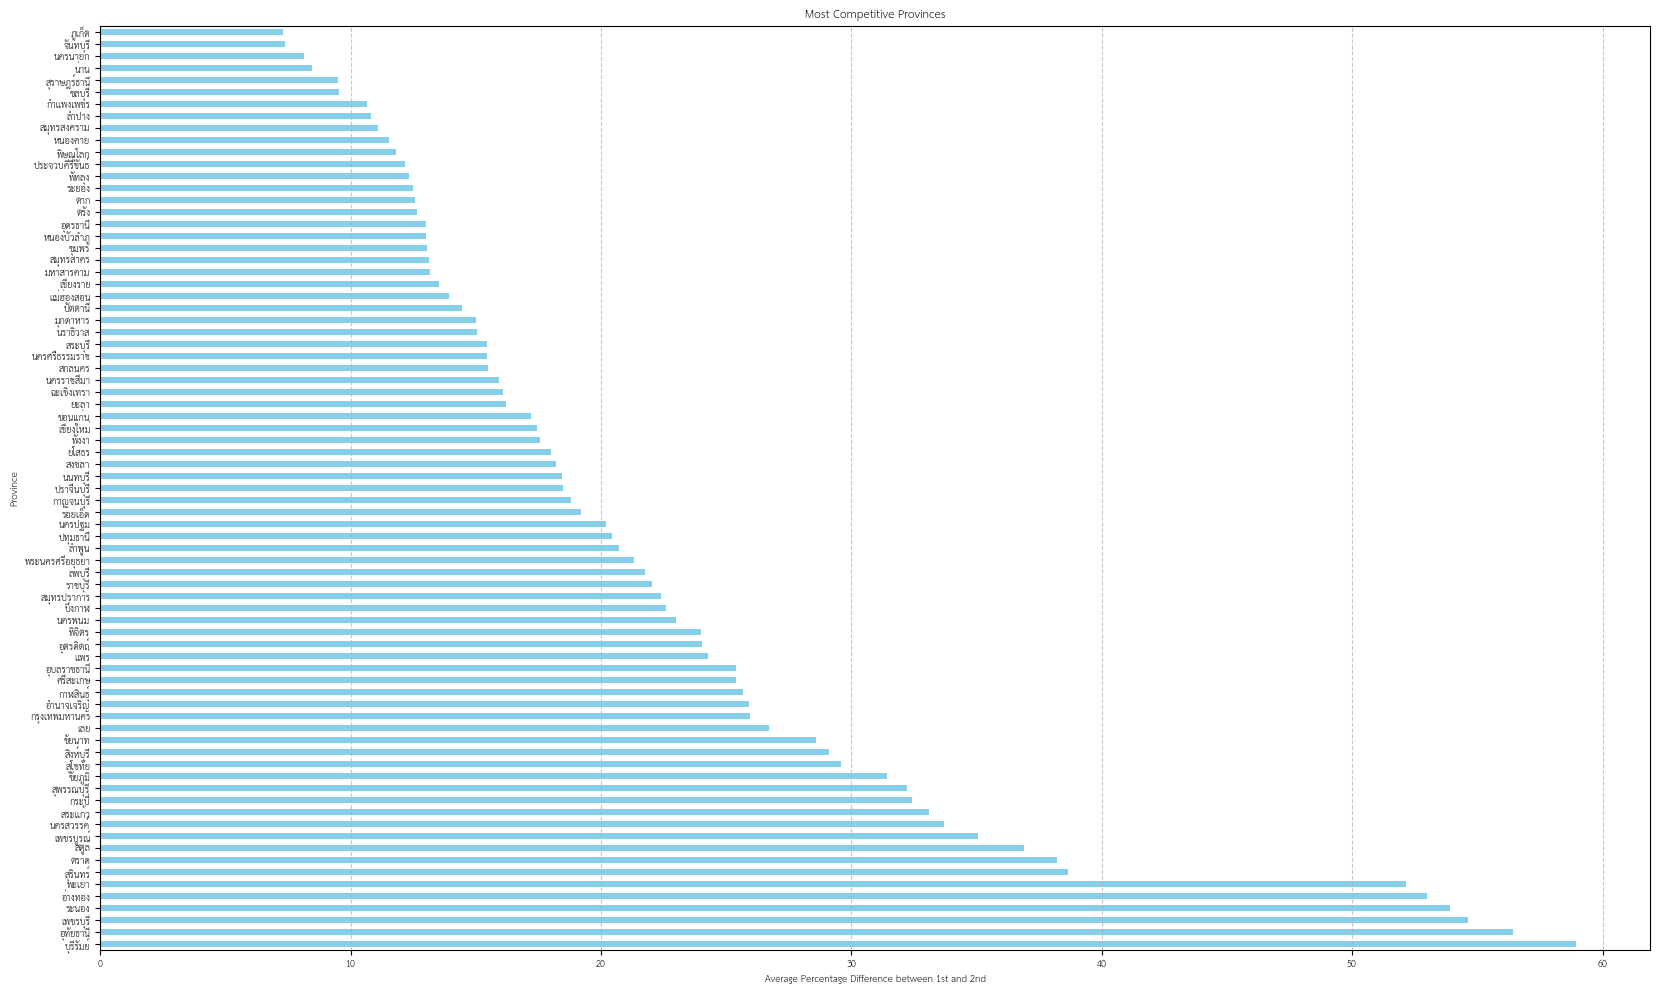

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))
province_competition.plot(kind='barh', color='skyblue')

plt.title('Most Competitive Provinces')
plt.xlabel('Average Percentage Difference between 1st and 2nd')
plt.ylabel('Province')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

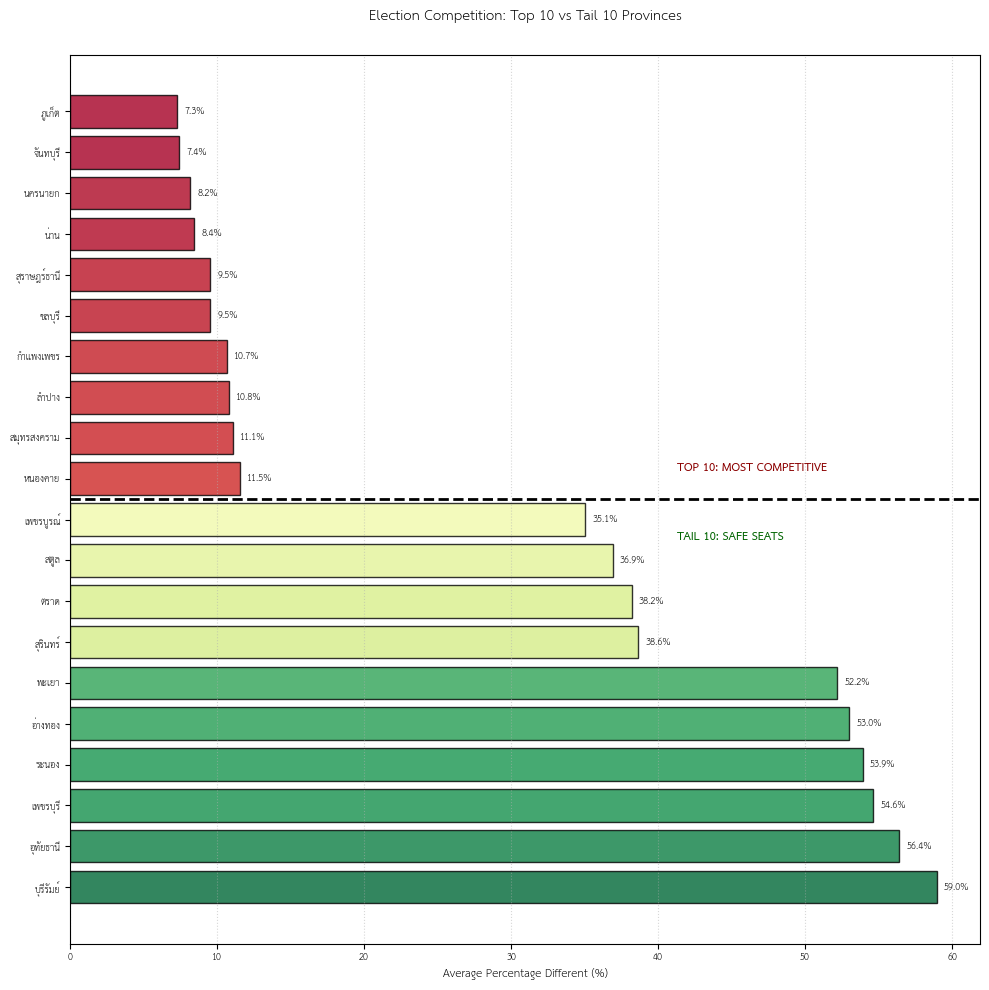

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

combined = pd.concat([province_competition.head(10), province_competition.tail(10)]).sort_values()

norm = plt.Normalize(combined.min(), combined.max())
colors = cm.RdYlGn(norm(combined.values))

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(combined.index, combined.values, color=colors, edgecolor='black', alpha=0.8)

split_index = 10 
ax.axhline(y=split_index - 0.5, color='black', linestyle='--', linewidth=2)

ax.text(combined.max()*0.7, split_index - 1.2, 'TOP 10: MOST COMPETITIVE', 
        color='darkred', fontweight='bold', fontsize=12)
ax.text(combined.max()*0.7, split_index + 0.5, 'TAIL 10: SAFE SEATS', 
        color='darkgreen', fontweight='bold', fontsize=12)

ax.set_title('Election Competition: Top 10 vs Tail 10 Provinces', fontsize=15, pad=25)
ax.set_xlabel('Average Percentage Different (%)', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', linestyle=':', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
df

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
0,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ปารเมศ วิทยารักษ์สรรค์,32564,5,2026-02-07T16:49:10.564Z,44.39,1,46,#ff6412,พรรคประชาชน
1,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พีรวุฒิ พิมพ์สมฤดี,14018,9,2026-02-07T16:49:14.267Z,19.11,2,27,#70c0fd,พรรคประชาธิปัตย์
2,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ลลิดา เพริศวิวัฒนา,13661,1,2026-02-07T16:49:03.079Z,18.62,3,37,#131c5f,พรรคภูมิใจไทย
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,ญาณกิตติ์ ห่วงทรัพย์,5761,8,2026-02-07T16:49:13.129Z,7.85,4,9,#fe0000,พรรคเพื่อไทย
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,พลัฏฐ์ ศิริกุลพิสุทธิ์,1983,6,2026-02-07T16:49:11.214Z,2.70,5,6,#243180,พรรครวมไทยสร้างชาติ
...,...,...,...,...,...,...,...,...,...,...,...
3484,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,พนธกร ใจสนอง,12618,4,2026-02-07T16:49:08.376Z,19.84,3,46,#ff6412,พรรคประชาชน
3485,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,สมภพ คงความซื่อ,2068,1,2026-02-07T16:49:04.719Z,3.25,4,9,#fe0000,พรรคเพื่อไทย
3486,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,สติ ทรัพย์ทวีพันธ์,1017,3,2026-02-07T16:49:08.063Z,1.60,5,6,#243180,พรรครวมไทยสร้างชาติ
3487,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 2,ภานุวัฒน์ คงมีความดี,931,6,2026-02-07T16:49:11.851Z,1.46,6,27,#70c0fd,พรรคประชาธิปัตย์


In [ ]:
df.groupby("candidateNumber")["rank"].agg("mean")

candidateNumber
1      4.062972
2      4.375000
3      4.376263
4      4.335013
5      4.382278
6      4.875661
7      5.705706
8      6.827586
9      5.430108
10     9.042735
11     7.527778
12     9.956522
13    10.083333
14    10.344828
15    10.150000
16    12.866667
17    10.600000
18    14.000000
19    19.000000
Name: rank, dtype: float64

In [35]:
pivot_rank = df.pivot_table(
    index='candidateNumber', 
    values='rank', 
    aggfunc='mean'
)

pivot_rank = pivot_rank.sort_values('rank')
pivot_rank

,rank
candidateNumber,
1,4.062972
4,4.335013
2,4.375000
3,4.376263
5,4.382278
6,4.875661
9,5.430108
7,5.705706
8,6.827586


In [42]:
candidate_count = df.groupby(['province', 'constituency'])["candidateNumber"].count().reset_index()
candidate_count.columns = ['province', 'constituency', 'candidate_total']
candidate_count

,province,constituency,candidate_total
0,กระบี่,กระบี่ เขต 1,6
1,กระบี่,กระบี่ เขต 2,7
2,กระบี่,กระบี่ เขต 3,6
3,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 1,18
4,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 10,16
...,...,...,...
395,แพร่,แพร่ เขต 1,6
396,แพร่,แพร่ เขต 2,5
397,แพร่,แพร่ เขต 3,6
398,แม่ฮ่องสอน,แม่ฮ่องสอน เขต 1,5


In [44]:
candidate_count_freq = candidate_count["candidate_total"].value_counts().reset_index()
candidate_count_freq

,candidate_total,count
0,7,75
1,8,75
2,9,62
3,6,52
4,10,47
5,11,24
6,5,15
7,12,12
8,16,9
9,14,9


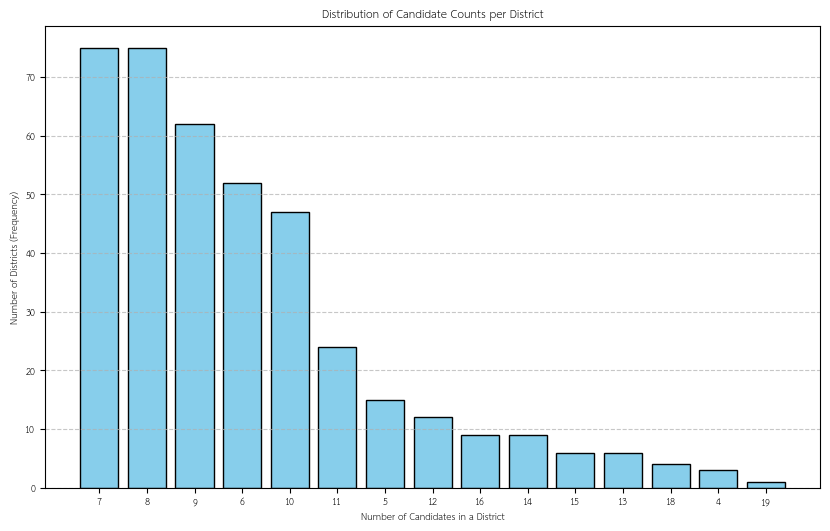

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(candidate_count_freq['candidate_total'].astype(str), candidate_count_freq['count'], color='skyblue', edgecolor='black')

plt.title('Distribution of Candidate Counts per District')
plt.xlabel('Number of Candidates in a District')
plt.ylabel('Number of Districts (Frequency)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
top3_rank_df = df[df['rank'].isin([1, 2, 3])]

rank_pivot = top3_rank_df.pivot_table(
    index='candidateNumber', 
    columns='rank', 
    values='fullName',
    aggfunc='count',
    fill_value=0
).reset_index()

rank_pivot.columns = ['candidateNumber','R1', 'R2', 'R3']
rank_pivot['mean_rank'] = ((1 * rank_pivot['R1']) + (2 * rank_pivot['R2']) + (3 * rank_pivot['R3'])) / (rank_pivot['R1'] + rank_pivot['R2'] + rank_pivot['R3'])
rank_pivot

,candidateNumber,R1,R2,R3,mean_rank
0,1,58,61,68,2.053476
1,2,61,64,63,2.010638
2,3,63,65,56,1.961957
3,4,55,65,55,2.000000
4,5,74,44,59,1.915254
5,6,34,43,39,2.043103
6,7,26,30,24,1.975000
7,8,13,14,17,2.090909
8,9,4,5,8,2.235294
9,10,3,3,2,1.875000


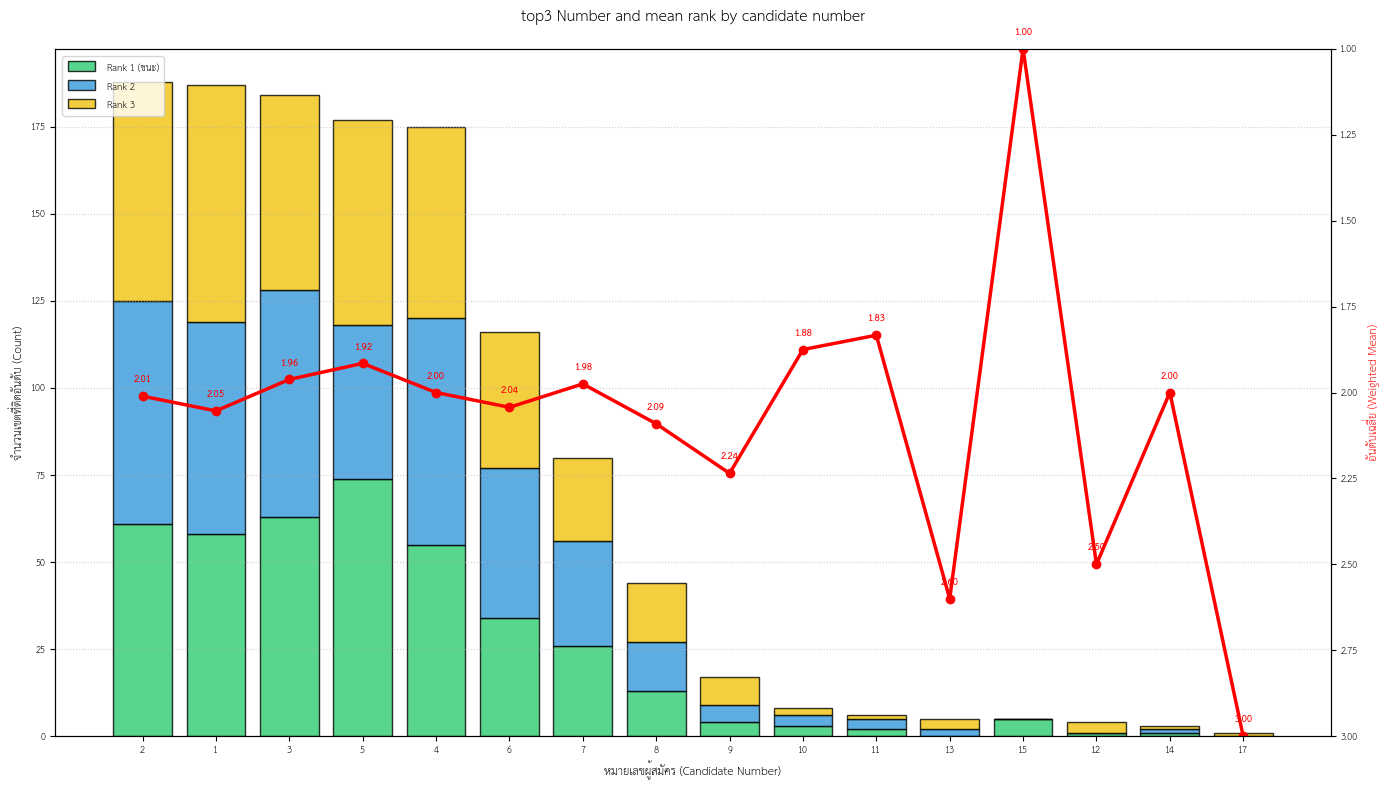

In [56]:
import matplotlib.pyplot as plt

rank_pivot['total_top3'] = rank_pivot['R1'] + rank_pivot['R2'] + rank_pivot['R3']
plot_df = rank_pivot.sort_values('total_top3', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 8))

# --- แกนซ้าย: พลอตแท่งซ้อน (R1, R2, R3) ---
x = plot_df['candidateNumber'].astype(str)
ax1.bar(x, plot_df['R1'], color='#2ecc71', label='Rank 1 (ชนะ)', edgecolor='black', alpha=0.8)
ax1.bar(x, plot_df['R2'], bottom=plot_df['R1'], color='#3498db', label='Rank 2', edgecolor='black', alpha=0.8)
ax1.bar(x, plot_df['R3'], bottom=plot_df['R1'] + plot_df['R2'], color='#f1c40f', label='Rank 3', edgecolor='black', alpha=0.8)

ax1.set_xlabel('หมายเลขผู้สมัคร (Candidate Number)', fontsize=12)
ax1.set_ylabel('จำนวนเขตที่ติดอันดับ (Count)', fontsize=12)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(x, plot_df['mean_rank'], color='red', marker='o', linewidth=2.5, label='Mean Rank (1-3)')
ax2.set_ylabel('อันดับเฉลี่ย (Weighted Mean)', color='red', fontsize=12)
ax2.set_ylim(1, 3) 
ax2.invert_yaxis() 

for i, val in enumerate(plot_df['mean_rank']):
    ax2.annotate(f'{val:.2f}', (i, val), textcoords="offset points", xytext=(0,10), 
                 ha='center', color='red', fontweight='bold')

plt.title('top3 Number and mean rank by candidate number', fontsize=16, pad=20)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [58]:
df[(df["candidateNumber"] == 15) & (df["rank"] ==1)]

,province,constituency,fullName,totalVotes,candidateNumber,updatedAt,percent,rank,party.code,party.color,party.name
34,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 11,ศศินันท์ ธรรมนิฐินันท์,36844,15,2026-02-07T16:49:15.052Z,40.91,1,46,#ff6412,พรรคประชาชน
52,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 12,ภูริวรรธก์ ใจสำราญ,44824,15,2026-02-07T16:49:15.052Z,47.72,1,46,#ff6412,พรรคประชาชน
234,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 23,ชลธาร ทรัพย์ไพบูลย์เลิศ,44381,15,2026-02-07T16:49:15.312Z,49.76,1,46,#ff6412,พรรคประชาชน
348,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 30,ธัญธร ธนินวัฒนาธร,44737,15,2026-02-07T16:49:15.052Z,49.82,1,46,#ff6412,พรรคประชาชน
383,กรุงเทพมหานคร,กรุงเทพมหานคร เขต 32,ปวิตรา จิตตกิจ,36963,15,2026-02-07T16:49:15.052Z,46.17,1,46,#ff6412,พรรคประชาชน


In [79]:
party_mode_df = df.groupby("party.name")["candidateNumber"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).reset_index()

party_mode_df.columns = ['party_name', 'mode_candidate_number']
party_mode_df

,party_name,mode_candidate_number
0,พรรคกรีน,5
1,พรรคกล้าธรรม,4
2,พรรคก้าวอิสระ,5
3,พรรคครูไทยเพื่อประชาชน,8
4,พรรคคลองไทย,4
5,พรรคความหวังใหม่,15
6,พรรคทางเลือกใหม่,8
7,พรรคท้องที่ไทย,1
8,พรรคประชากรไทย,9
9,พรรคประชาชน,2


In [80]:
top1_df = df[df["rank"]==1].reset_index()
top1_party_mode_df = top1_df.groupby("party.name")["candidateNumber"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).reset_index()

top1_party_mode_df.columns = ['party_name', 'rank1_mode_candidate_number']
top1_party_mode_df

,party_name,rank1_mode_candidate_number
0,พรรคกล้าธรรม,3
1,พรรคประชาชน,7
2,พรรคประชาชาติ,3
3,พรรคประชาธิปัตย์,5
4,พรรคพลังประชารัฐ,3
5,พรรคภูมิใจไทย,5
6,พรรคเพื่อไทย,1
7,พรรคโอกาสใหม่,4
8,พรรคไทยสร้างไทย,4
9,พรรคไทรวมพลัง,5


In [85]:
party_mode_compare = pd.merge(
    top1_party_mode_df,
    party_mode_df, 
    on='party_name', 
    how='left', 
    suffixes=('_overall', '_winner')
)
party_mode_compare

,party_name,rank1_mode_candidate_number,mode_candidate_number
0,พรรคกล้าธรรม,3,4
1,พรรคประชาชน,7,2
2,พรรคประชาชาติ,3,1
3,พรรคประชาธิปัตย์,5,5
4,พรรคพลังประชารัฐ,3,6
5,พรรคภูมิใจไทย,5,5
6,พรรคเพื่อไทย,1,1
7,พรรคโอกาสใหม่,4,2
8,พรรคไทยสร้างไทย,4,5
9,พรรคไทรวมพลัง,5,2


In [86]:
party_mode_compare[party_mode_compare["rank1_mode_candidate_number"]==party_mode_compare["mode_candidate_number"]]

,party_name,rank1_mode_candidate_number,mode_candidate_number
3,พรรคประชาธิปัตย์,5,5
5,พรรคภูมิใจไทย,5,5
6,พรรคเพื่อไทย,1,1


In [ ]:
partyStand = partyStand.sort_values(by="id").reset_index()
